# Prédiction du score d'addiction à l'alcool
## Modèles de Machine Learning (comparaison et analyse) 

**Dataset :** Students-mat   
**Variable cible :** `Dalc` — Nombre de verres d'alcool par jour

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

In [7]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)
from sklearn.model_selection import GridSearchCV


from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor

## 2 - Chargement et preprocessing

On charge le dataset, séparons les données de la variable que l'on veut prédire et on convertit les variables textuelles en nombres avec `LabelEncoder` et `oneHotEncoder`.

Ensuite on sépare les données en 80% entraînement / 20% test.

In [8]:
data_mat = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,6,5,6,6
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,4,5,5,6
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,10,7,8,10
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,2,15,14,15
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,4,6,10,10


In [9]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]


In [10]:
categorical_cols = data_mat.drop(["Dalc","Walc"],axis=1).columns
data_mat1 = data_mat.drop(["Dalc","Walc"],axis=1)
print(categorical_cols)


Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='str')


In [11]:
print(data_mat1.dtypes)
data_mat1.describe()


sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [12]:
data_mat2 = data_mat1.copy()


### Prétraitement des données

In [13]:
from models.encoder import labelEncoder, oneHotEncoder

data_mat_labenc = labelEncoder(data_mat2)
data_mat_labenc.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,18,1,0,0,4,4,0,4,0,...,0,0,4,3,4,3,6,5,6,6
GP,0,17,1,0,1,1,1,0,2,0,...,1,0,5,3,3,3,4,5,5,6
GP,0,15,1,1,1,1,1,0,2,2,...,1,0,4,3,2,3,10,7,8,10
GP,0,15,1,0,1,4,2,1,3,1,...,1,1,3,2,2,5,2,15,14,15
GP,0,16,1,0,1,3,3,2,2,1,...,0,0,4,3,2,5,4,6,10,10


OneHotEncoder créé une nouvelle colonne pour chaque catégorie possible. Chaque colonne contient 1 si l'individu appartient à la catégorie, sinon 0. 
Les catégories ne sont plus hiérarchisées mais cela augmente grandement le nombre de colonne. 

L'argument sparse_output=False permet de stocker les données dans un tableau numpy

handle_unknown='ignore' évite les erreurs si une catégorie apparaît dans le test mais pas dans le train

In [14]:
data_mat_ohe = oneHotEncoder(data_mat2)
data_mat_ohe.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,18,1,0,0,4,4,0,4,0,...,0,0,4,3,4,3,6,5,6,6
GP,0,17,1,0,1,1,1,0,2,0,...,1,0,5,3,3,3,4,5,5,6
GP,0,15,1,1,1,1,1,0,2,2,...,1,0,4,3,2,3,10,7,8,10
GP,0,15,1,0,1,4,2,1,3,1,...,1,1,3,2,2,5,2,15,14,15
GP,0,16,1,0,1,3,3,2,2,1,...,0,0,4,3,2,5,4,6,10,10


Séparation des jeux de données encoder par label encoder et onehotencoder

In [15]:
X_train, X_test, y_train, y_test = train_test_split(data_mat_labenc, y, test_size=0.2, random_state=0)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(data_mat_ohe, y, test_size=0.2, random_state=0)


Standardisation des données suivis du PAC

In [16]:
from models.ACP import ACP

df_labenc_acp = ACP(data_mat_labenc)
df_ohe_acp = ACP(data_mat_ohe)

print(df_labenc_acp)

[[-1.84061148  1.44288943 -0.19305275 ... -0.21738829  0.35592811
   1.34581836]
 [-2.80459668 -0.00645485 -1.44147792 ...  0.37625093  0.43521696
   0.25876995]
 [-2.38345802 -0.05872788 -1.96730336 ... -0.03585734 -0.55303536
  -1.14742725]
 ...
 [-4.57719757 -3.13421887  1.41094655 ... -0.46067195  0.95180096
   0.00887062]
 [-0.93517215 -2.60488964  1.44859959 ...  0.01828906 -0.5511765
   0.93666639]
 [-1.87207495 -1.91532811  0.09608581 ... -0.21381045  0.95990758
   1.3953776 ]]


In [17]:
X_train_stand, X_test_stand, y_train_stand, y_test_stand = train_test_split(df_labenc_acp, y, test_size=0.2, random_state=0)


In [19]:
test = LogisticRegression()
test.fit(X_train, y_train)
test.score(X_test, y_test)

c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6835443037974683

In [20]:
test = LogisticRegression()
test.fit(X_train_ohe, y_train_ohe)
test.score(X_test_ohe, y_test_ohe)


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6835443037974683

In [21]:
test = LogisticRegression()
test.fit(X_train_stand, y_train_stand)
test.score(X_test_stand, y_test_stand)

0.7468354430379747

In [22]:
test = LogisticRegression()
test.fit(X_train_stand_ohe, y_train_stand_ohe)
test.score(X_test_stand_ohe, y_test_stand_ohe)


0.7468354430379747

In [23]:
test = RandomForestClassifier(n_estimators=100, max_depth=1)
test.fit(X_train_stand, y_train_stand)
test.score(X_test_stand, y_test_stand)

0.7974683544303798

In [24]:
test = RandomForestClassifier(n_estimators=100, max_depth=1)
test.fit(X_train, y_train)
test.score(X_test, y_test)

0.7974683544303798

In [25]:
test = RandomForestClassifier(n_estimators=100, max_depth=1)
test.fit(X_train_stand_ohe, y_train_stand_ohe)
test.score(X_test_stand_ohe, y_test_stand_ohe)

0.7974683544303798

## 4 Entrainement de différents modèles d'apprentissage

La première méthode consiste à effectuer l'entrainement des données à l'aide de la fonction 'cross_val_score' qui sépare le jeu de donnée en 'cv=5' groupe avant d'entrainer les données sur chacun d'entre eux et tester son score sur le dernier groupe.

In [26]:
clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

NameError: name 'data_sortie_ohe' is not defined

Les modèles de régressions ne sont ici pas performant, particulièrement en comparaison avec les modèles de classifications. 

In [ ]:
clf = DecisionTreeClassifier(max_depth=1, min_samples_split=2,
    random_state=0)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = RandomForestClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=0)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = ExtraTreesClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=1)
scores = cross_val_score(clf, data_sortie_ohe, y, cv=5)
print(scores)
print(scores.mean())

scores.mean() > 0.999

[0.70886076 0.65822785 0.67088608 0.63291139 0.69620253]
0.6734177215189874
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899


np.False_

In [ ]:
def nbr_estimator_model(model,n_estim=100):
    best = 0
    best_k=0
    for k in range (1,n_estim,1):
        model_train = model(n_estimators=k)
        model_train.fit(X_train_stand_ohe, y_train_stand_ohe)
        score = model_train.score(X_test_stand_ohe, y_test_stand_ohe)
        if(best<score):
            best=score
            best_k=k
    print("best : ",best_k,best)
    return [best_k,best]

In [ ]:
nbr_estimator_model(AdaBoostClassifier)

best :  1 0.7974683544303798


[1, 0.7974683544303798]

In [ ]:
modeles = {
    "decision_tree_regressor": DecisionTreeRegressor(),
    "XGBRegressor":XGBRegressor(n_estimators=100,random_state=42),
    "decision_tree_classifier": DecisionTreeClassifier(),
    "random_forest_classifier": RandomForestClassifier(n_estimators=10, max_depth=3),
    "logistic_regression": LogisticRegression(max_iter=1000),
    "gaussian_nb": GaussianNB(),
    "sgd_classifier": SGDClassifier(random_state=1),
    "knn_classifier": KNeighborsClassifier(n_neighbors=5),
    "bagging_classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)

}

Best=None
score_Best=0
list_model_voting = []
for nom, model in modeles.items():
    model.fit(X_train_stand_ohe, y_train_stand_ohe)
    score_model = model.score(X_test_stand_ohe,y_test_stand_ohe)
    print(f"{nom} : {score_model:.4f}")
    if score_model >score_Best:
        Best=model
        score_Best=score_model
    if(score_model >0.5):
        list_model_voting.append((nom, model))
        
model_0 = VotingClassifier(list_model_voting,
                          voting='hard')
model_0.fit(X_train_stand_ohe, y_train_stand_ohe)
model_0.score(X_test_stand_ohe, y_test_stand_ohe)

model_stack = StackingClassifier(list_model_voting,
                             final_estimator=model_0)
model_stack.fit(X_train_stand_ohe, y_train)
model_stack.score(X_test_stand_ohe, y_test_stand_ohe)

if(score_Best>model_0.score(X_test_stand_ohe, y_test_stand_ohe)):
    best=model_0
if(score_Best>model_stack.score(X_test_stand_ohe, y_test_stand_ohe)):
    best=model_stack
print(f"\n\nMeilleur modèle : {best.__class__.__name__} avec un score de {score_Best:.4f}\n\n")

decision_tree_regressor : -1.8187
XGBRegressor : -0.5884
decision_tree_classifier : 0.5949
random_forest_classifier : 0.7975
logistic_regression : 0.6962
gaussian_nb : 0.6962
sgd_classifier : 0.7089
knn_classifier : 0.7468
bagging_classifier : 0.7848


Meilleur modèle : VotingClassifier avec un score de 0.7975




c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Métriques

y_pred_base = Best.predict(X_test_stand_ohe)

mae  = mean_absolute_error(y_test_stand_ohe, y_pred_base)
rmse = np.sqrt(mean_squared_error(y_test_stand_ohe, y_pred_base))
r2   = r2_score(y_test_stand_ohe, y_pred_base)

print("=== Résultats — Modèle de Base ===")
print(f"  MAE  (erreur absolue moyenne) : {mae:.3f}")
print(f"  RMSE (racine erreur quadr.)   : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n Le modèle explique {r2*100:.1f}% de la variance du score")


=== Résultats — Modèle de Base ===
  MAE  (erreur absolue moyenne) : 0.329
  RMSE (racine erreur quadr.)   : 0.871
  R²   (coefficient de détermination) : -0.166

 Le modèle explique -16.6% de la variance du score


In [ ]:
# Validation croisée (5-fold)
cv_scores = cross_val_score(Best, data_sortie_ohe, y, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R^2 moyen  : {cv_scores.mean():.4f}")
print(f"  Écart-type : {cv_scores.std():.4f}")


=== Validation Croisée (5-fold) ===
  Fold 1: R² = -0.2964
  Fold 2: R² = -0.2928
  Fold 3: R² = -0.2776
  Fold 4: R² = -0.2016
  Fold 5: R² = -0.2928

  R^2 moyen  : -0.2723
  Écart-type : 0.0359


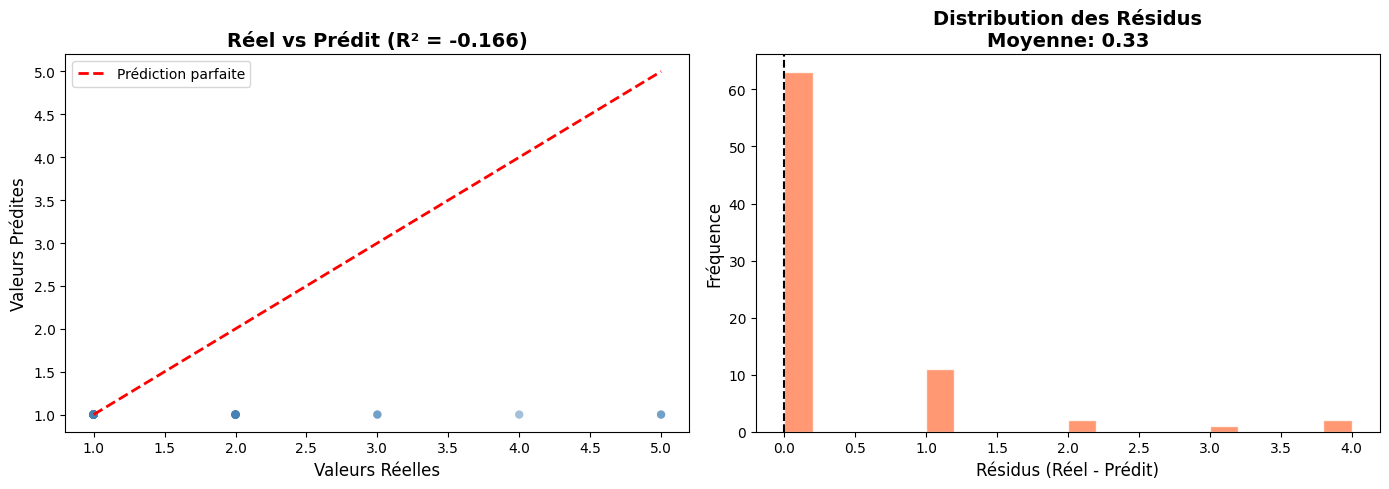

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test_stand_ohe, y_pred_base, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test_stand_ohe.min(), y_test_stand_ohe.max()], [y_test_stand_ohe.min(), y_test_stand_ohe.max()],
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles', fontsize=12)
axes[0].set_ylabel('Valeurs Prédites', fontsize=12)
axes[0].set_title(f'Réel vs Prédit (R² = {r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()

# Distribution des Résidus
residuals = y_test_stand_ohe - y_pred_base
axes[1].hist(residuals, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.2f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# On crée un faux profil d'étudiant pour tester
# Note : Il doit avoir exactement les mêmes colonnes que data_mat_final (après OneHot)
nouveau_profil = X_test[0:1] # On prend le premier étudiant du test pour l'exemple

# --- TYPE 1 : Prédiction de Classe (Classification) ---
classe_predite = model.predict(nouveau_profil)
probabilites = model.predict_proba(nouveau_profil) # Probabilité pour chaque niveau (1 à 5)

print(f"Classe prédite (Niveau de consommation) : {classe_predite[0]}")
print(f"Confiance du modèle : {np.max(probabilites)*100:.2f}%")

# --- TYPE 2 : Prédiction de Score Continu (Si on utilisait un Régresseur) ---
# Si vous aviez utilisé XGBRegressor ou RandomForestRegressor :
# score_continu = model_regresseur.predict(nouveau_profil)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_final_pred = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_final_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('Réalité (Vrai score Dalc)')
plt.xlabel('Prédiction (Score prédit)')
plt.title('Matrice de Confusion : Où le modèle se trompe-t-il ?')
plt.show()

print(classification_report(y_test, y_final_pred))

Cette matrice confirme les analyses que nous avons déjà effectuées dans le notebook de prévisualisation des données : notre jeu de donnée contient une grande majorité de valeur 1 pour la variable Dalc, ce qui fait que notre modèle atteint un score d'accuracy de 0.80 uniquement en prédisant 1. 